### Load data for training
1. CSV file with SMILES and bruker filenames
2. Root directory (if used) of bruker .0 files

SMILES are reduced to largest fragment and canonicalized

Spectra are transformed to absorbance, baseline corrected, and normalized

Expected 496 spectral files

In [1]:
from ir_processing import TrainingData

# since using OOB for F1 score calculation, there will be small variations
# in final model results based on the order of the training data. Order
# is dictated by the csv file
training_data = TrainingData(
                    csv_path  = "../training_data/smiles_to_file_V2.csv",
                    spec_root = "../training_data",
                )

print(f"Records imported for training: {training_data.size()}")

/Users/evansjr/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Records imported for training: 496


### Automatic processing of training data

Data is shaped for input to the classification model. 

Each functional group is default sampled with 16 points to normalize vector lengths.

Functional groups lacking sufficient representation (< 5 instances) are masked.


In [2]:
from modeling import SpectIRmodeling

# if run without the training_data input, the model will try
# to initialize from a previously saved training
cls_model = SpectIRmodeling(training_data)

INFO: Training data provided. Initializing training pipeline...
/Users/evansjr/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/evansjr/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/evansjr/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/evansjr/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/evansjr/anaconda3/lib/python3.11/

### Model training

Expected training shape:
    X_regional shape: (496, 848)
    Y_filtered shape: (496, 37)
        
Default training has Out-Of-Bag flag set to True to calculate precision, recall and F1

Expected results (precision, recall, F1):
1. OVERALL (Samples): 0.748  0.855  0.784           
2. OVERALL  (Macro) : 0.602  0.581  0.573           

In [3]:
print(cls_model.summary)

Final data shape: X=(496, 848), Y=(496, 37)
OOB Metrics (Per-Compound / Samples): Precision=0.748, Recall=0.855, F1-Score=0.784
OOB Metrics (Per-Class / Macro):      Precision=0.602, Recall=0.581, F1-Score=0.573


### Load search library

Provide either a path to the .csv/.tsv (new library) or .parquet (saved library)

For new libraries:
1. SMILES are reduced to largest fragment and canonicalized

2. Exact mass, protonated, and sodiated are caclulated.

3. Boolean flag if compound contains an odd number of nitrogens

4. Functional groups assigned based on SMARTS

In [4]:
from smiles_library import load_smiles_library

library_df  = load_smiles_library("../stored/coconut_csv-05-2026.csv")

INFO: Loaded 738,827 compounds from file.
INFO: Processing 738,827 compounds in 148 chunks on 7 workers...
[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:    7.6s
[Parallel(n_jobs=7)]: Done  58 tasks      | elapsed:  1.1min
[Parallel(n_jobs=7)]: Done 148 out of 148 | elapsed:  2.6min finished
INFO: Done: 738,528 valid compounds successfully processed.
INFO: Saving library to ../stored/coconut_csv-05-2026.parquet


### Test and reporting

In [5]:
import importlib
import pandas as pd
import numpy as np
from sklearn.multioutput import MultiOutputClassifier

import report
import search
importlib.reload(report)
importlib.reload(search)

# from source_1.modeling import predict_fg_from_spectra
from ir_processing import Spectrum
from search import search_library
from report import build_report_html, plot_spectrum

def find_and_report(
    spectra_dir:  str, 
    spectra_file: str, 
    test_smiles:  str,
    mw:           float,
    model:        SpectIRmodeling,
    search_id:    str   = None,
    tanimoto:     float = 0.6,
    top_n:        int   = 5000,
    search_mw:    str   = "protonated",
    training_data: pd.DataFrame = None,
    group_stereo: bool  = True,
) -> pd.DataFrame:
    
    fpath = spectra_dir + spectra_file
    
    # includes transformation to absorbance, normalize to max peak and baseline correct
    spectrum = Spectrum(fpath, spectra_file, test_smiles)

    # predict the functional groups assigned by random forest model
    predicted_fgs = model.predict_fg_from_spectra(spectrum.wn, spectrum.absorbance)
    
    # plot the search spectra
    fig = plot_spectrum(spectrum.wn, spectrum.absorbance, title=f"third stage spectra: {spectra_file}", smiles='', show_regions=predicted_fgs)
    
    # gather results and counts
    results, mw_count = search_library(
        query_fgs   = predicted_fgs,
        library_df  = library_df,
        mw          = mw,
        top_n       = top_n,
        tanimoto    = tanimoto,
        search_mw   = search_mw,
    )
    
    if group_stereo:
        # group the results by parent coconut identifier. From the COCONUT paper:
        # 'Stereochemical variants of the same molecule are grouped under the same 
        # identifier and are issued a unique postfix to the COCONUT identifier.''
        results = results.groupby(results["parent"]).agg({
            "rank_score":       "mean",
            "fg_set":           "first",
            "smiles":           "first",
            "name":             "first",
            "molecular_weight": "first",
            "fg_len":           "max"
        })

        # add back the identifier and re-sort
        results["id"] = results.index
        results.sort_values(
            by=['rank_score', "fg_len"], 
            inplace=True, 
            ascending=[False, False], 
            ignore_index=True
        )
    
    # generate the html report and open in default browser
    build_report_html(
        spectrum_fig = fig,
        query_fgs    = predicted_fgs,
        candidates   = results,
        query_name   = spectra_file,
        top_n        = 50,
        output_path  = f"../reports/{spectra_file}.html",
        search_stats = {
            "mw_count": mw_count,
            "fg_count": len(results),
        },
        search_param = {
            "mw":        mw,
            "search_mw": search_mw,
            "tanimoto":  tanimoto,
            "test_smi":  test_smiles,
        },
        training_data= training_data.spectra,
        FG_CONFIDENCE= model.confidence,
    )

Report written to /Users/evansjr/jupyter-notebooks/bondmap/reports/16220300001_D2.0.html


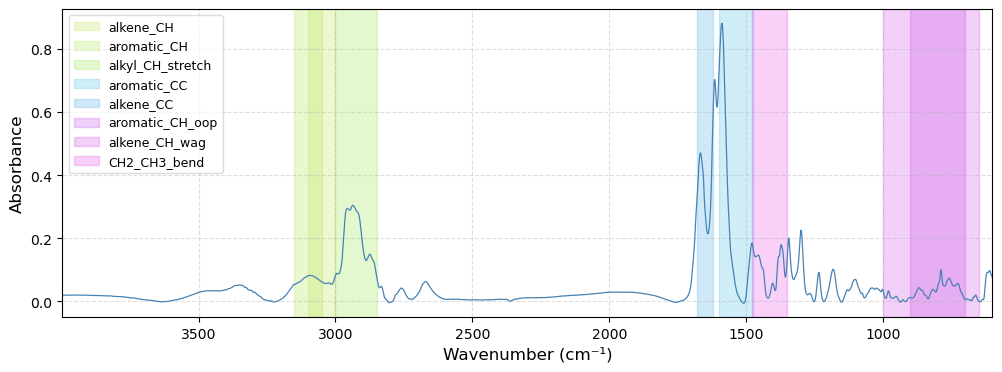

In [6]:
# agelasine
find_and_report(
    "../test_data/", 
    "16220300001_D2.0", 
    "C[C@@H]1CC[C@@]2([C@@H]([C@@]1(C)CC/C(=C/CN3C=[N+](C4=NC=NC(=C43)N)C)/C)CCC=C2C)C",
    422.33,
    cls_model,
    search_id = "CNP0572110.6",
    search_mw = "exact",
    tanimoto = 0.8,
    training_data = training_data,
)

Report written to /Users/evansjr/jupyter-notebooks/bondmap/reports/MTP_9_H11.0.html


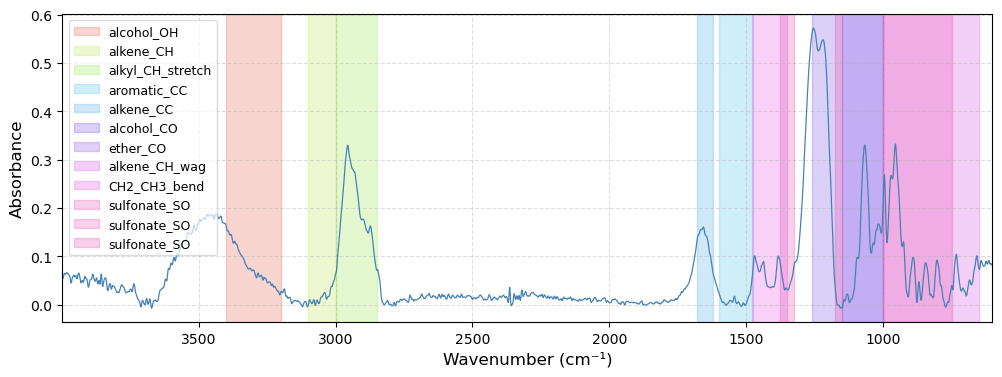

In [7]:
# excluded from duplicates
find_and_report(
    "../test_data/", 
    "MTP_9_H11.0", 
    "CC(C)CCC[C@@H](C)[C@H]1CC[C@@]2(C)[C@@H]3C[C@H](OS(=O)(=O)O)[C@H]4C[C@H](OS(=O)(=O)O)[C@@H](OS(=O)(=O)O)C[C@]4(C)C3=CC[C@]12C.[Na].[Na].[Na]",
    672.23+1.007,
    cls_model,
    search_id = "CNP0572110.6",
    search_mw = "protonated",
    tanimoto = 0.8,
    training_data = training_data,
)

Report written to /Users/evansjr/jupyter-notebooks/bondmap/reports/16220300001_F11.0.html


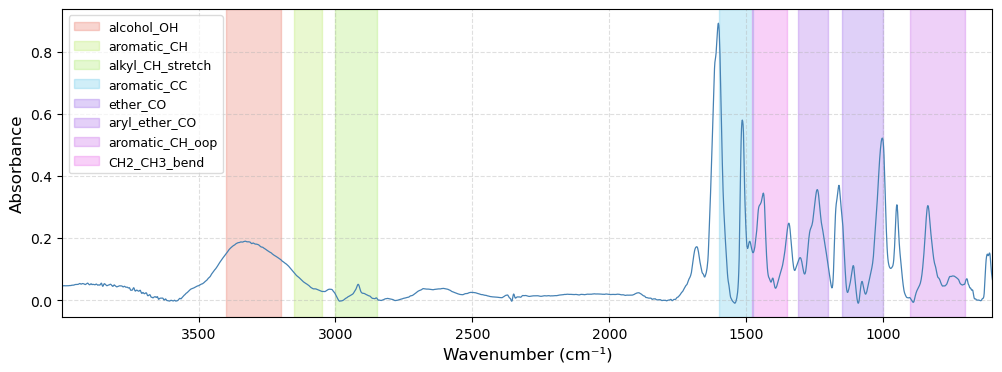

In [8]:
# stilbenoids L17383_4
find_and_report(
    "../test_data/", 
    "16220300001_F11.0", 
    "C1=CC(=CC=C1/C=C/C2=C3[C@@H]([C@H](OC3=CC(=C2)O)C4=CC=C(C=C4)O)C5=CC(=C6C(C(OC6=C5)C7=CC=C(C=C7)O)C8=CC(=CC(=C8)O)O)O)O",
    681.22,
    cls_model,
    search_id = "CNP0188679.2",
    search_mw = "protonated",
    tanimoto  = 0.7,
    training_data = training_data
)

Report written to /Users/evansjr/jupyter-notebooks/bondmap/reports/16220300012_B11.0.html


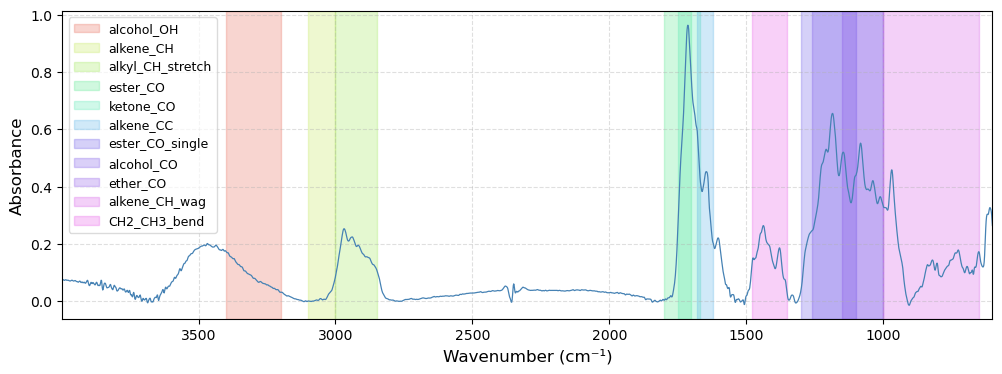

In [9]:
# tricothecenes
find_and_report(
    "../test_data/", 
    "16220300012_B11.0", 
    "CC1=C[C@@H]2[C@]3(COC(/C=C(C)/CCO[C@@H]([C@H](O)C)/C=C/C=C\C(OC4[C@]3(C)[C@@]5([C@H](O2)C4)CO5)=O)=O)CC1",
    537.2464,
    cls_model,
    search_id = "CNP0373612.4",
    search_mw = "sodiated",
    tanimoto = 0.9,
    training_data = training_data
)

Report written to /Users/evansjr/jupyter-notebooks/bondmap/reports/16220300003_C6.0.html


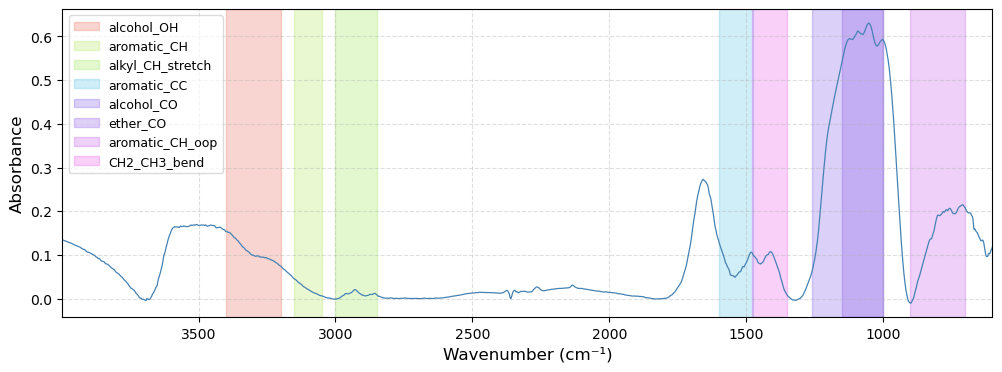

In [10]:
# Anthraquinones
find_and_report(
    "../test_data/", 
    "16220300003_C6.0", 
    "O=C1C2=C(O)C=C(O)C=C2C(C3=C1C(O)=CC(O)=C3C(C)=O)=O",
    315.0, # 
    # 395.3636,
    cls_model,
    search_id = "CNP0171092.0",
    search_mw = "protonated",
    tanimoto  = 0.7,
    training_data = training_data
)

Report written to /Users/evansjr/jupyter-notebooks/bondmap/reports/16220300001_A8.0.html


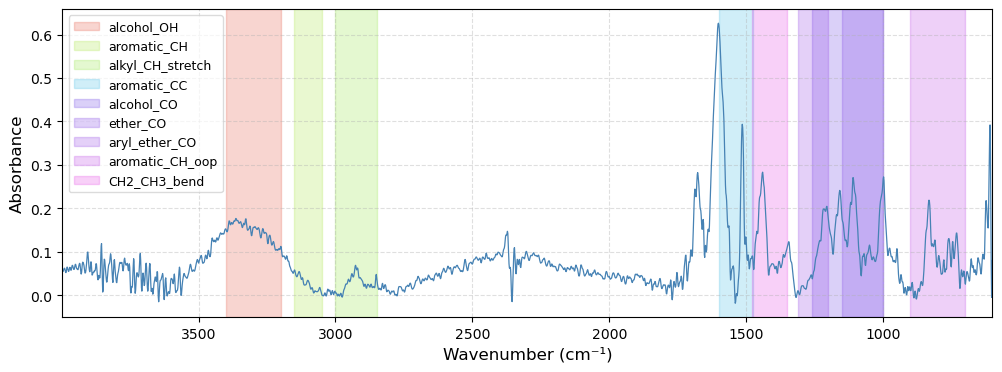

In [11]:
# stilbenoids L40225_4
find_and_report(
    "../test_data/", 
    "16220300001_A8.0", 
    "C1=CC(=CC=C1/C=C/C2=C3[C@@H]([C@H](OC3=CC(=C2)O)C4=CC=C(C=C4)O)C5=CC(=C6C(C(OC6=C5)C7=CC=C(C=C7)O)C8=CC(=CC(=C8)O)O)O)O",
    681.22,
    cls_model,
    search_id = "CNP0188679.2",
    search_mw = "protonated",
    tanimoto  = 0.7,
    training_data = training_data
)

Report written to /Users/evansjr/jupyter-notebooks/bondmap/reports/16220300002_B6.0.html


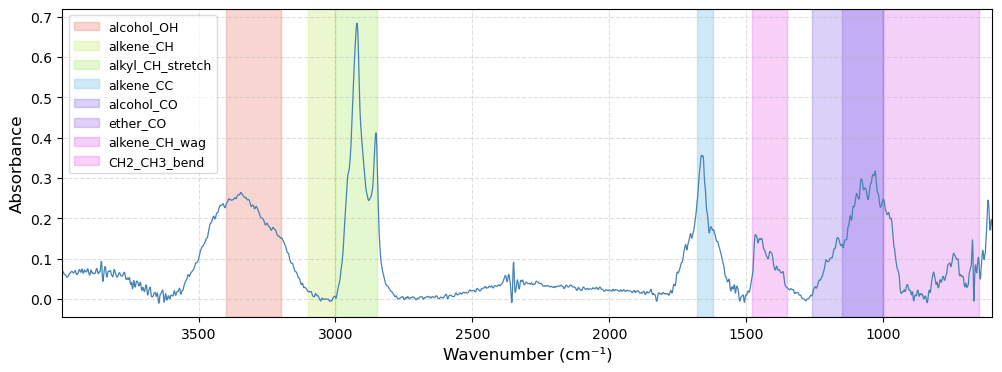

In [12]:
# cerebrosides
find_and_report(
    "../test_data/", 
    "16220300002_B6.0", 
    "CCCCCCCCCCCCCCCCCC(O)=N[C@@]([C@@](O)([H])/C([H])=C([H])/CCCCCCCCCCC)([H])CO[C@@]1([H])[C@@](O)([H])[C@](O)([H])[C@@](O)([H])[C@@](O1)([H])CO",
    700.57, # 
    # 614.4031,
    cls_model,
    search_id = None,
    search_mw = "protonated",
    tanimoto  = 0.2,
    training_data = training_data
)

Report written to /Users/evansjr/jupyter-notebooks/bondmap/reports/16220300012_A7.0.html


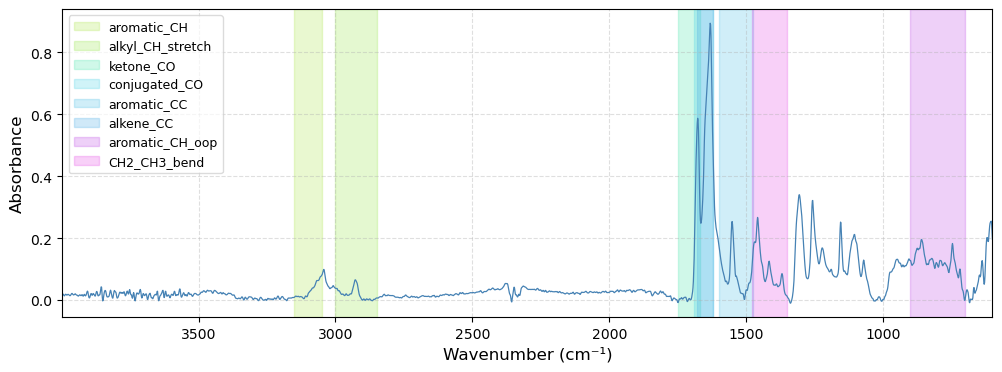

In [14]:
# Perfragilin B
find_and_report(
    "../test_data/", 
    "16220300012_A7.0", 
    "CN1C=C(C2=CC1=O)C(C(SC)=C(SC)C2=O)=O",
    # 315.26, # 
    282.0260,
    cls_model,
    search_id = "CNP0157927.0",
    search_mw = "protonated",
    tanimoto  = 0.8,
    training_data = training_data
)

Report written to /Users/evansjr/jupyter-notebooks/bondmap/reports/16220300012_D7.0.html


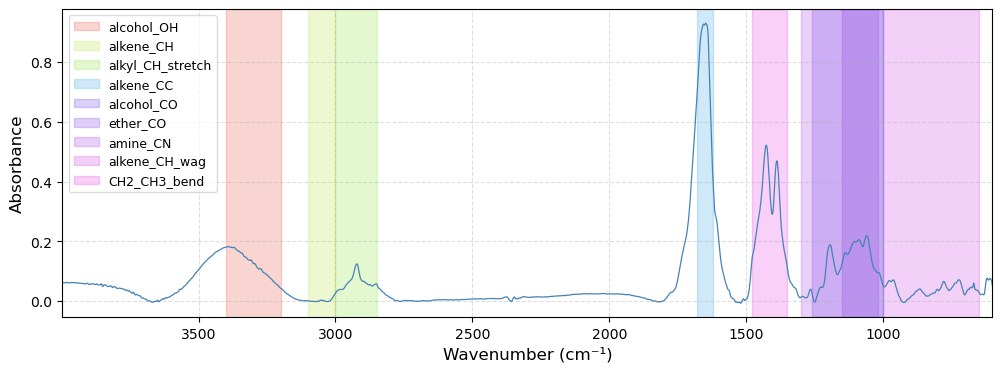

In [15]:
# Diketopiperazine class - Dimethylgliotoxin,Bis(Dethio)Bis(Methylthio)Gliotoxin H210459_4
find_and_report(
    "../test_data/", 
    "16220300012_D7.0", 
    "O=C1N(C)C(SC)(CO)C(N2C1(SC)CC3=CC=CC(O)C23[H])=O",
    # 315.26, # 
    357.0940,
    cls_model,
    search_id = "CNP0299713.1",
    search_mw = "protonated",
    tanimoto  = 0.8,
    training_data = training_data
)

Report written to /Users/evansjr/jupyter-notebooks/bondmap/reports/B6005093-IR.jdx.html


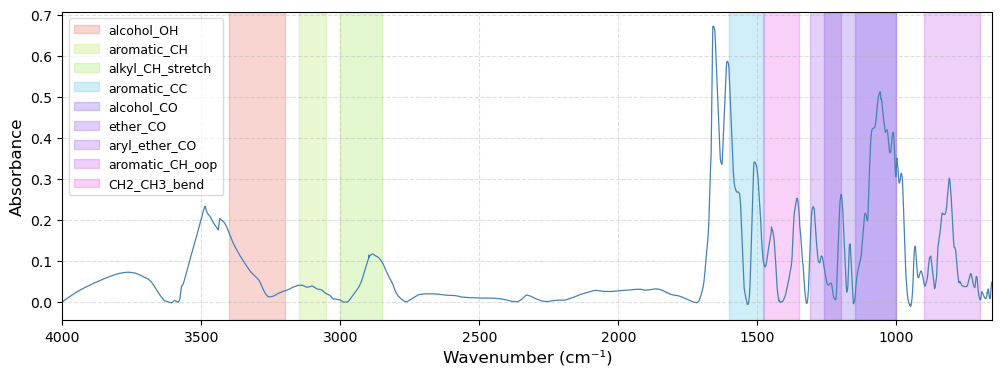

In [16]:
# rutin from NIST jdx file
find_and_report(
    "../test_data/", 
    "B6005093-IR.jdx", 
    "C[C@@H]1O[C@@H](OC[C@H]2O[C@@H](OC3=C(C4=CC=C(O)C(O)=C4)OC4=CC(O)=CC(O)=C4C3=O)[C@H](O)[C@@H](O)[C@@H]2O)[C@H](O)[C@H](O)[C@H]1O",
    # 315.26, # 
    611.160661,
    cls_model,
    search_id = "CNP0268715.1",
    search_mw = "protonated",
    tanimoto  = 0.8,
    training_data = training_data,
)